# Simple Visualizer for S2 datasets

In [2]:
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
import pathlib
import shapely
import fiona.transform
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def get_example_image(path, plot=True):
    """
    Loads example Sentinel-2 image from path to tif file
    :param path: Path to image file
    :param plot: If True, will plot an RGB image of the satellite image
    :return: Normalized image as torch tensor
    """
    with rasterio.open(path) as f:
            data = f.read().astype(np.float32)
            image = data / 10000.0
            B10 = np.zeros((1, *image.shape[1:]), dtype=image.dtype)
            image = np.concatenate([image[:10], B10, image[10:]], axis=0)
            image = torch.tensor(image)

            if plot:
                    # Read the first three RGB bands (assuming they are bands 4, 3, and 2)
                    red_band = f.read(4) / 10000.0
                    green_band = f.read(3) / 10000.0
                    blue_band = f.read(2) / 10000.0

                    # Stack the bands to create an RGB image
                    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Plot the RGB image
                    plt.imshow(rgb_image)
                    plt.title("RGB Sentinel-2 Image")
                    plt.axis('off')  # Hide axes
                    plt.show()

    return image

def get_metadata(path):
    """
    Loads metadata from a Sentinel-2 image file
    :param path: Path to image file
    :return: Metadata dictionary
    """
    tags = {}

    with rasterio.open(path) as src:
        geom = shapely.geometry.mapping(shapely.geometry.box(*src.bounds))
        warped_geom = fiona.transform.transform_geom(src.crs, "EPSG:4326", geom)
        shape = shapely.geometry.shape(warped_geom)
        x, y = shape.centroid.xy
        x = x[0]
        y = y[0]
        tags = src.tags()
        filename = pathlib.Path(path).name
        t = src.tags().get("datetime")
        id = src.tags().get("granule_id")

    return id, x, y, t, tags

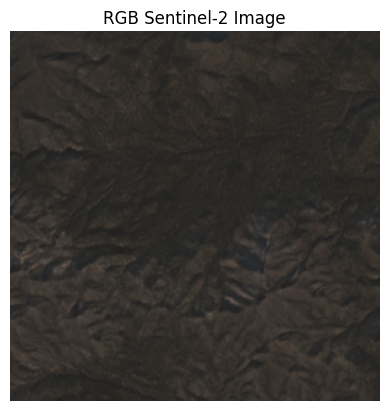

metadata for /home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_10038.tif:
  id: S2B_OPER_MSI_L2A_TL_2BPS_20241215T221457_A040622_T11SPC_N05.11
  x: -115.40981182441725
  y: 38.348611848975516
  t: 2024-12-15T18:26:59.024000+00:00


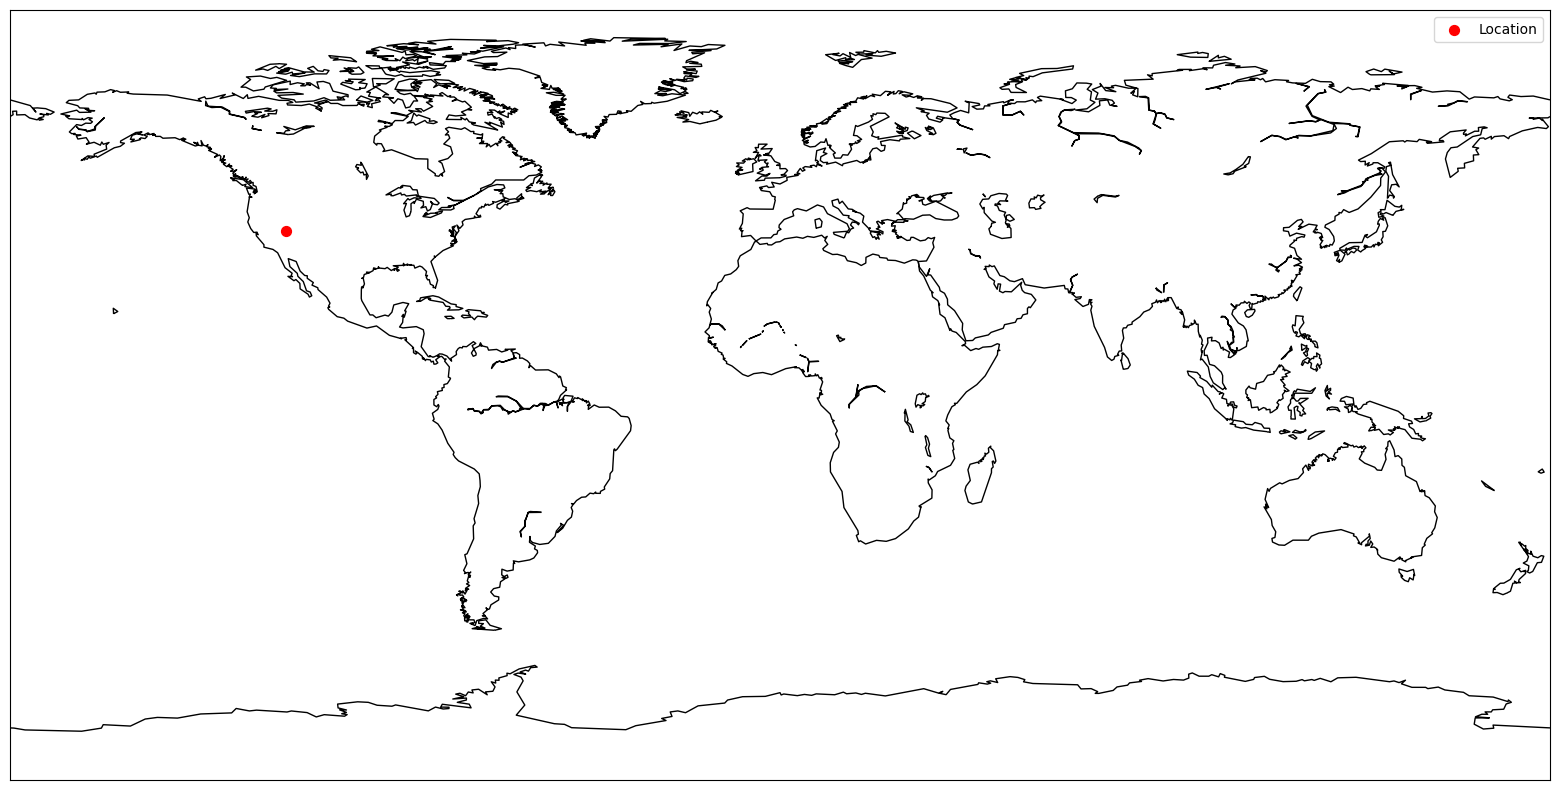

In [23]:
path = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_30.tif"
path = "/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_10038.tif"
# print example image
img = get_example_image(path, plot=True)

# print metadata
id, x, y, t, tags = get_metadata(path)

print(f"metadata for {path}:")
print(f"  id: {id}")
print(f"  x: {x}")
print(f"  y: {y}")
print(f"  t: {t}")
# print(f"  tags: {tags}")

#Plot true and predicted locations
fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
ax.scatter(x, y, s=50, c="red", label="Location")
ax.legend()

100%|██████████| 54050/54050 [09:08<00:00, 98.58it/s] 


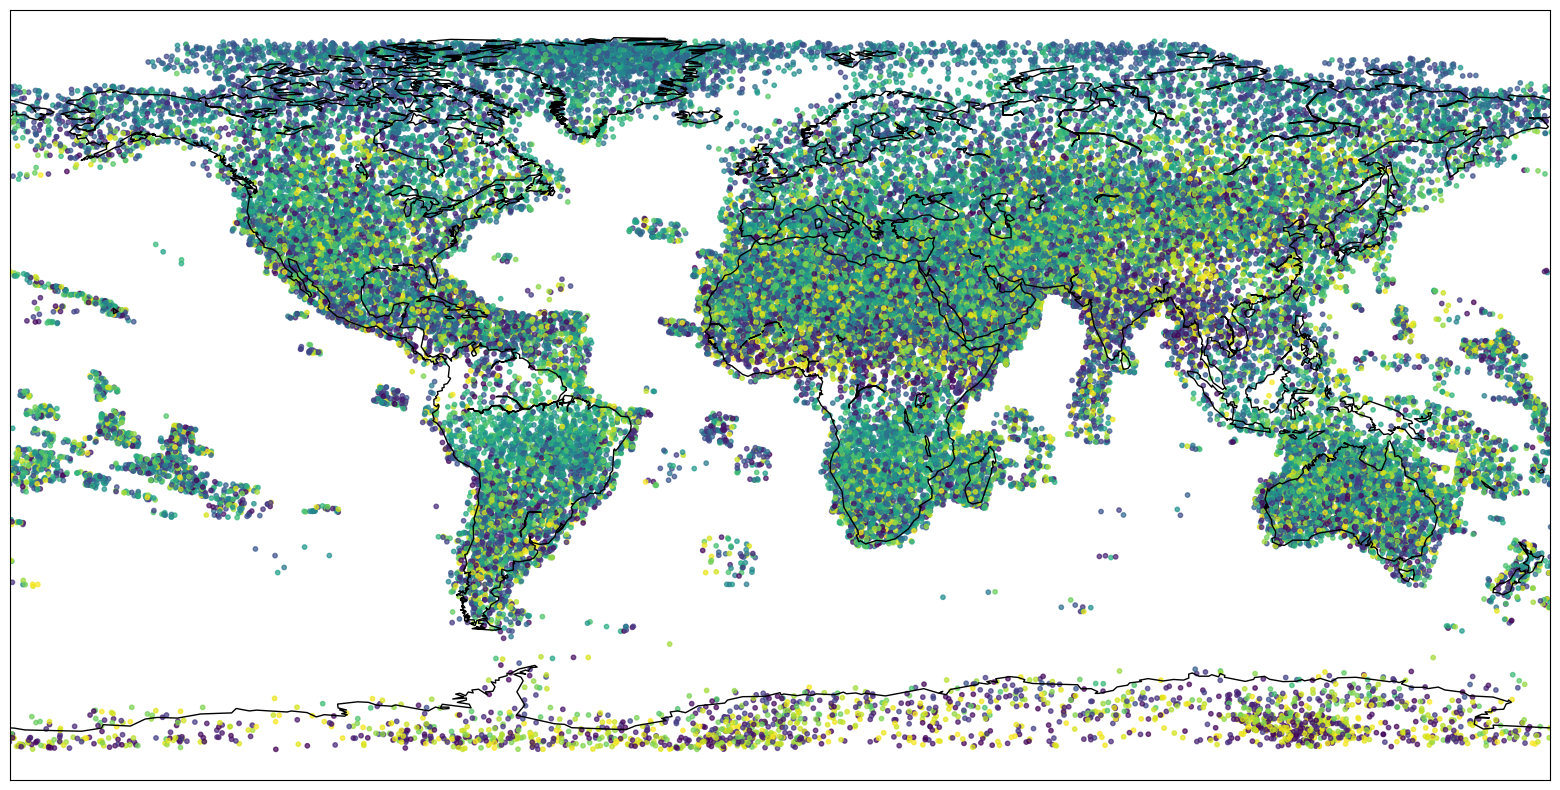

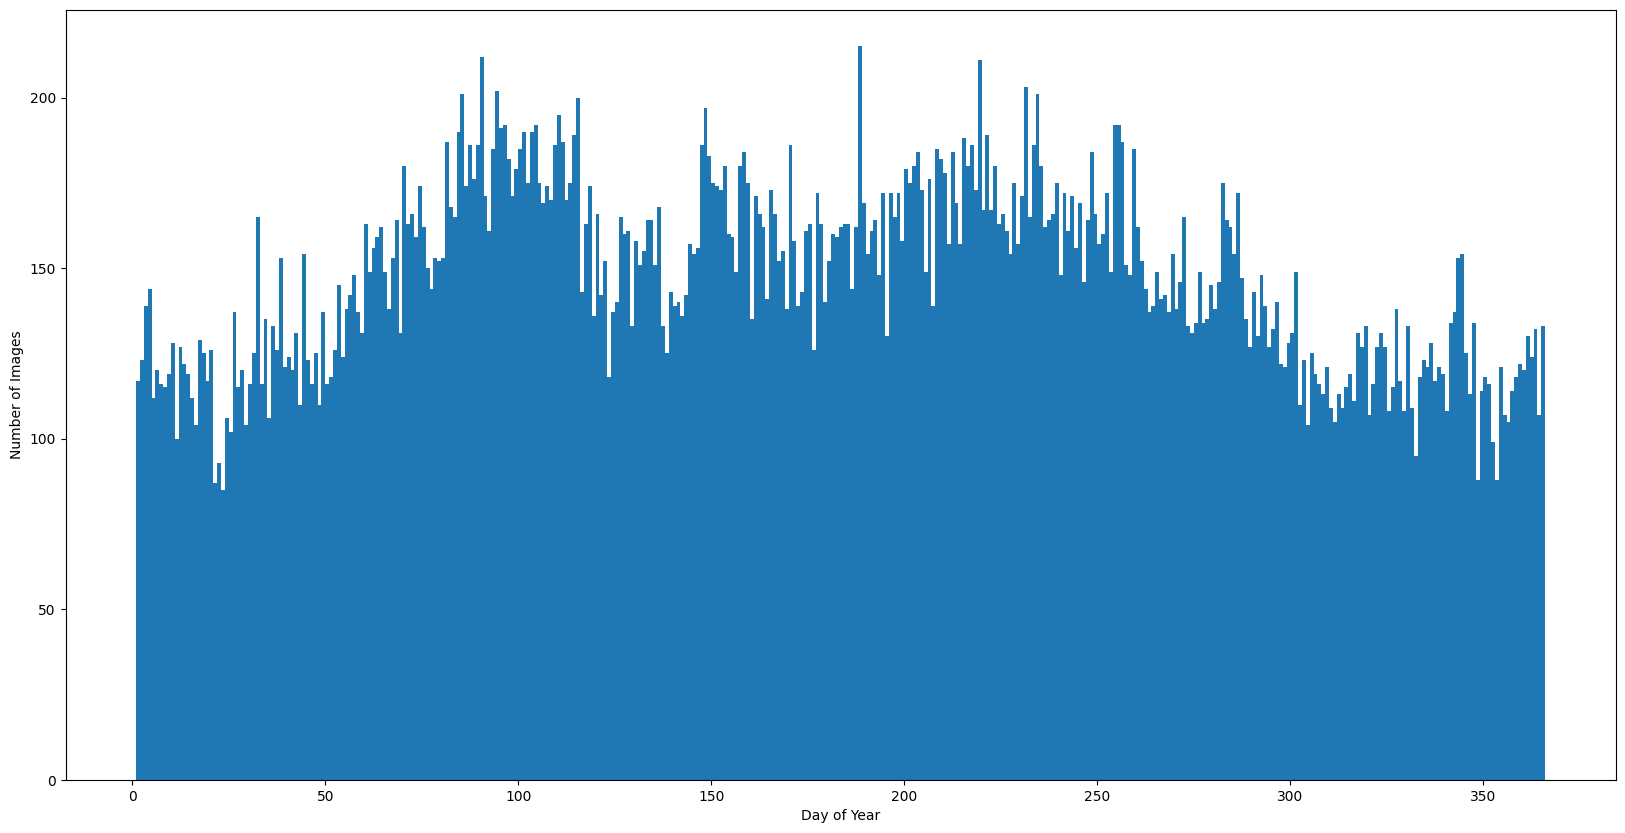

In [4]:
# Visualize the entire dataset
VISUALIZE_AVG_COLORS = True
import glob
import datetime
from tqdm import tqdm
img_root = "/home/leca5365/Datasets/satclip-s2-temporal-55k/images/"

img_paths = glob.glob(f"{img_root}/*.tif")

fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

doys = []
ts = []
xs = []
ys = []
avg_colors = []

def get_avg_color(path):
    with rasterio.open(path) as f:
        red_band = f.read(4).astype(np.float32) / 10000.0
        green_band = f.read(3).astype(np.float32) / 10000.0
        blue_band = f.read(2).astype(np.float32) / 10000.0

        avg_red = np.mean(red_band)
        avg_green = np.mean(green_band)
        avg_blue = np.mean(blue_band)
    return (avg_red, avg_green, avg_blue)

for img_path in tqdm(img_paths):
    id, x, y, t, tags = get_metadata(img_path)
    dt = datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00')
    doy = dt.timetuple().tm_yday
    doys.append(doy)
    xs.append(x)
    ys.append(y)
    ts.append(t)
    
    if VISUALIZE_AVG_COLORS:
        avg_colors.append(get_avg_color(img_path))

ax.scatter(xs, ys, s=10, c=doys, cmap='viridis', alpha=0.7) 
# fig.colorbar(fig.gca(), label='Day of Year', ax=ax)
# plt.show()

fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(doys, bins=365)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Number of Images')
plt.show()

In [5]:
import pandas as pd
if VISUALIZE_AVG_COLORS:
    df = pd.DataFrame({'d': doys, 't': ts, 'x': xs, 'y': ys, 'path': img_paths, 'avg_color': avg_colors})
else:
    df = pd.DataFrame({'d': doys, 't': ts, 'x': xs, 'y': ys, 'path': img_paths})
print(len(df))
df.head()


54050


,d,t,x,y,path,avg_color
0,34,2025-02-03T22:59:51.025000+00:00,169.731367,-11.750632,/home/leca5365/Datasets/satclip-s2-temporal-55...,"(0.13179584, 0.13661999, 0.15534458)"
1,296,2023-10-23T09:30:29.024000+00:00,14.243053,15.729858,/home/leca5365/Datasets/satclip-s2-temporal-55...,"(0.6197516, 0.47538257, 0.3511343)"
2,260,2023-09-17T23:52:31.024000+00:00,151.817035,-42.596827,/home/leca5365/Datasets/satclip-s2-temporal-55...,"(0.10686805, 0.11206116, 0.11933729)"
3,308,2022-11-04T11:42:59.024000+00:00,-85.425807,-80.211397,/home/leca5365/Datasets/satclip-s2-temporal-55...,"(1.0169339, 1.0461378, 1.0447078)"
4,187,2025-07-06T16:48:49.024000+00:00,-84.363188,51.699109,/home/leca5365/Datasets/satclip-s2-temporal-55...,"(0.13867804, 0.14729118, 0.12840408)"


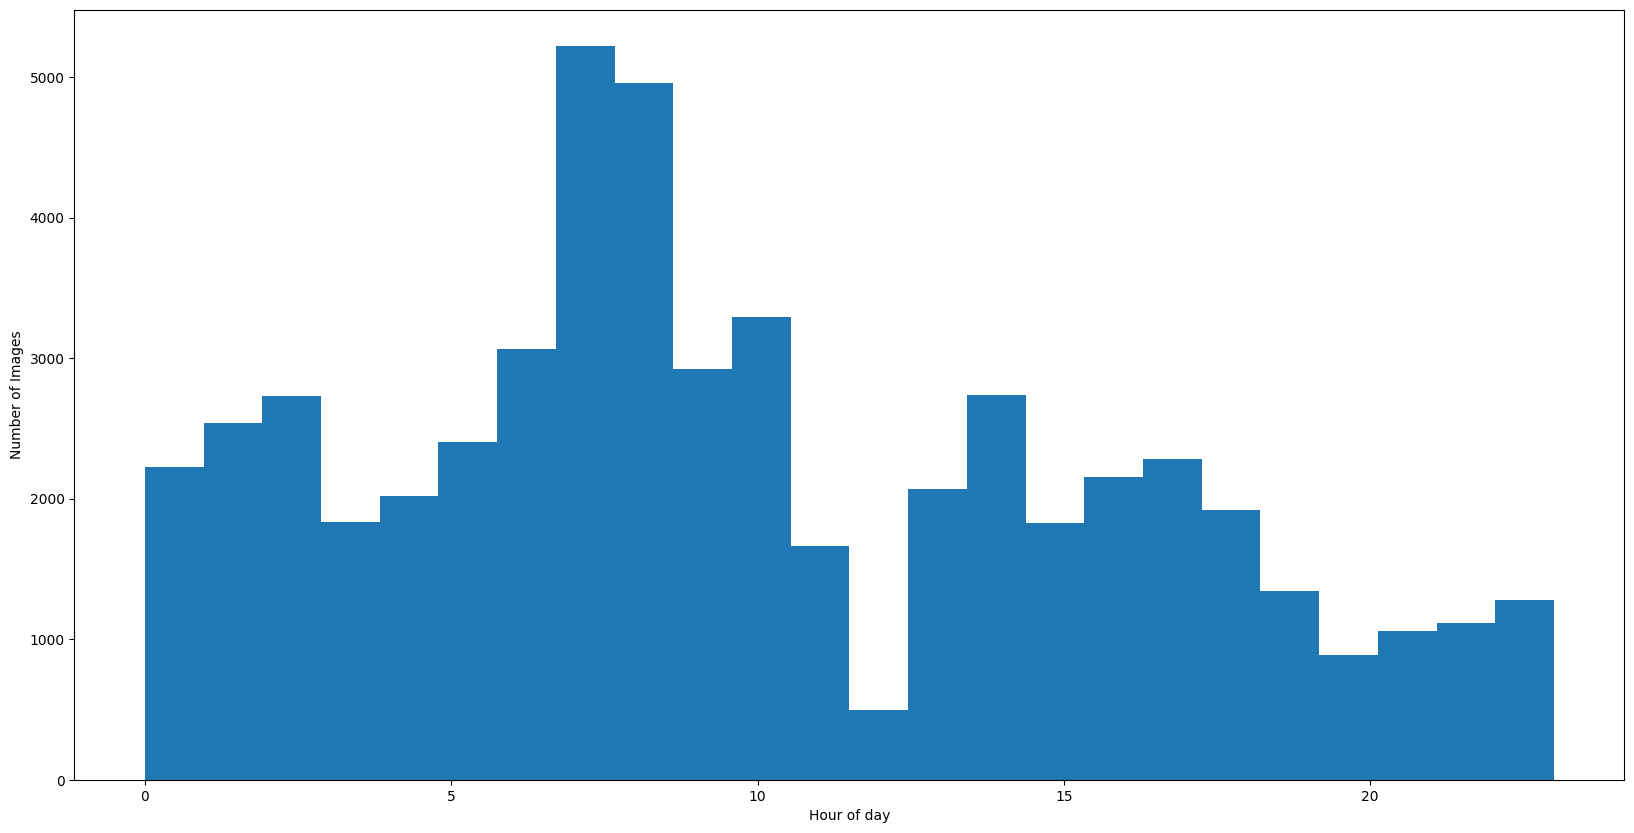

In [6]:
# TODO: transform from UTC to local time
hs = [datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00').hour for t in df['t']]
fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(hs, bins=24)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of Images')
plt.show()

100%|██████████| 7/7 [00:02<00:00,  2.38it/s]


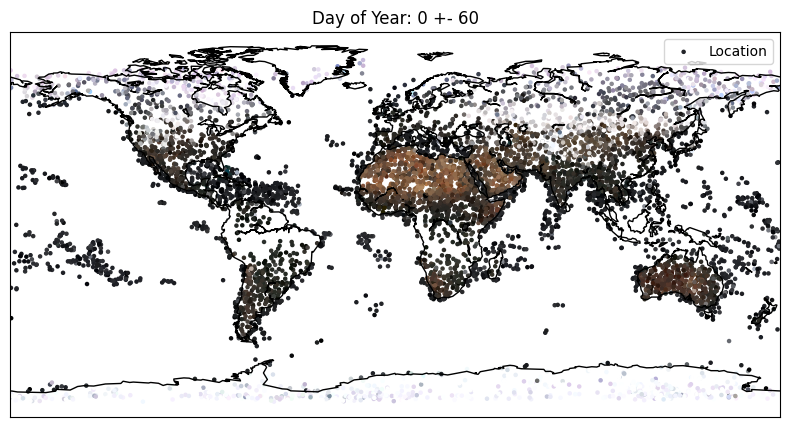

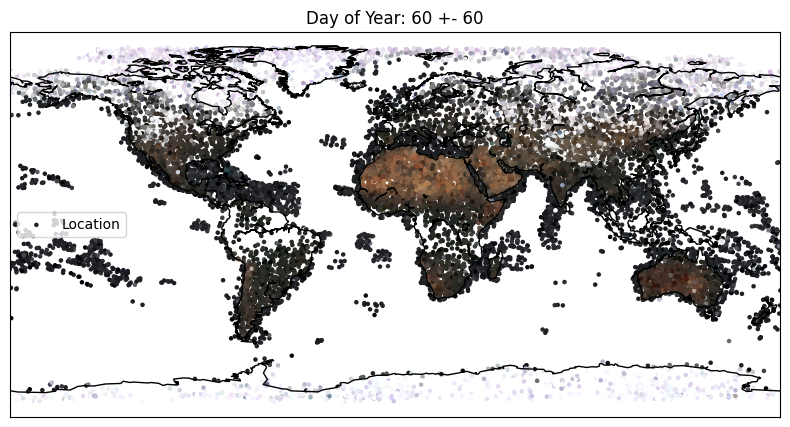

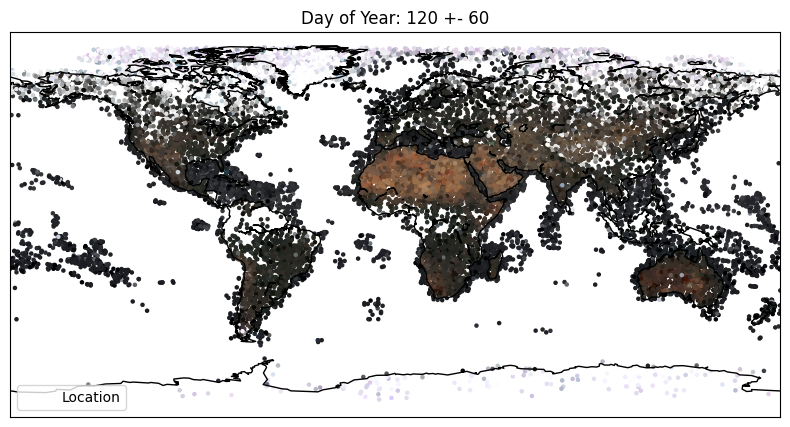

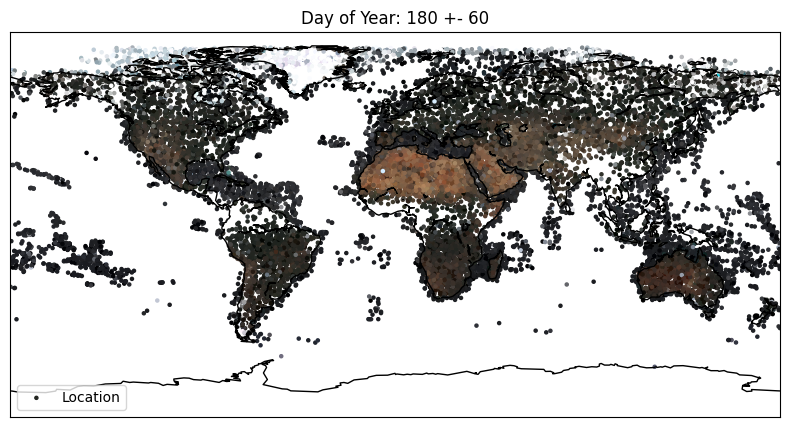

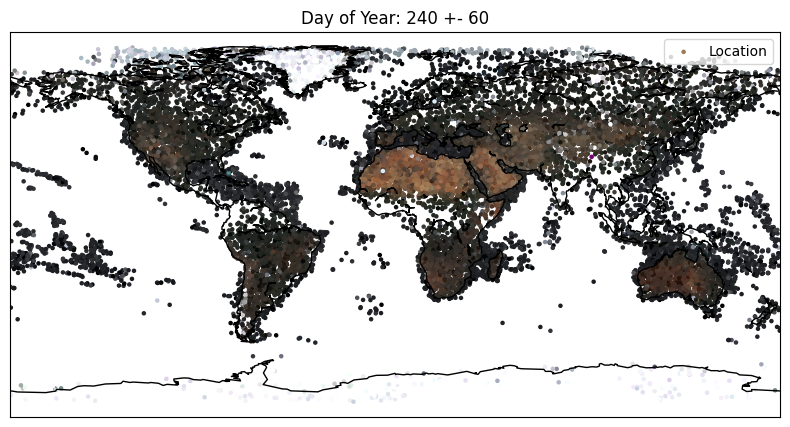

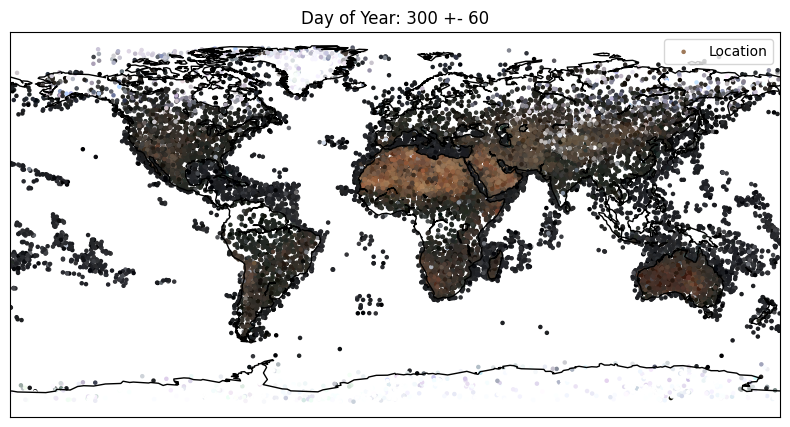

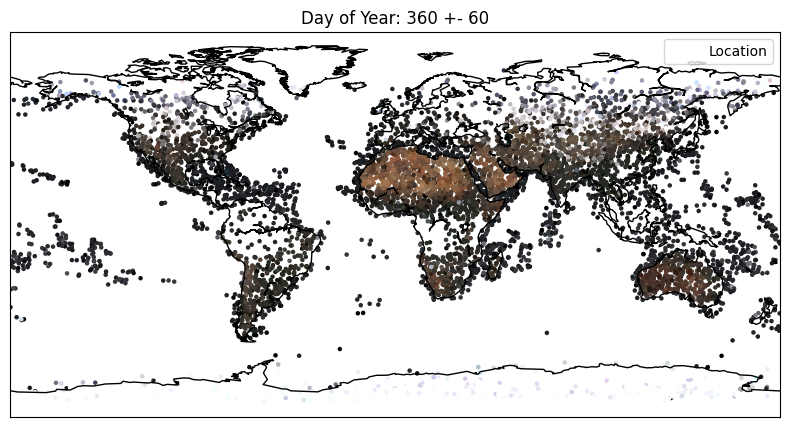

In [7]:
# Make a gif over time of the dataset
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

frames = []

days_win = 60

for doy in tqdm([0, 60, 120, 180, 240, 300, 360]):
    # Find images within a window of days
    df_window = df[(df['d'] >= doy - days_win) & (df['d'] <= doy + days_win)]

    cs = np.array([np.array(x) for x in df_window['avg_color'].values])
    cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    sc = ax.scatter(df_window['x'].values, df_window['y'].values, s=5, c=cs, label="Location")
    ax.set_title(f"Day of Year: {doy} +- {days_win}")
    ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))


# Save as GIF
frames[0].save('s2_temporal_dataset_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

100%|██████████| 13/13 [00:01<00:00,  7.26it/s]


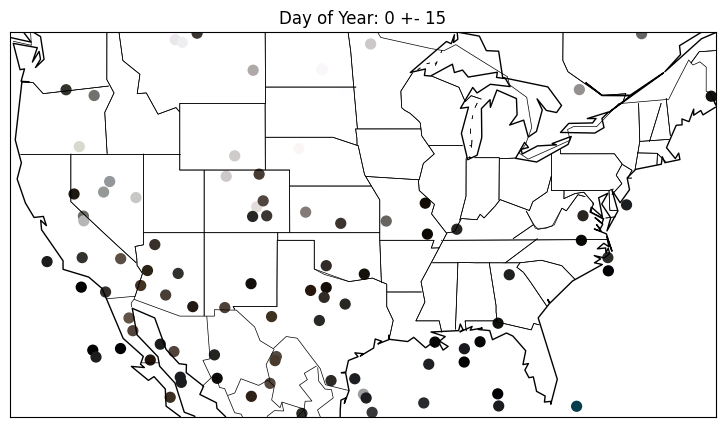

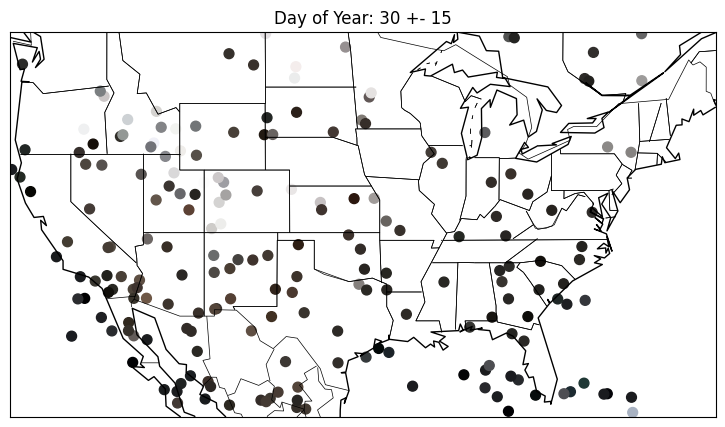

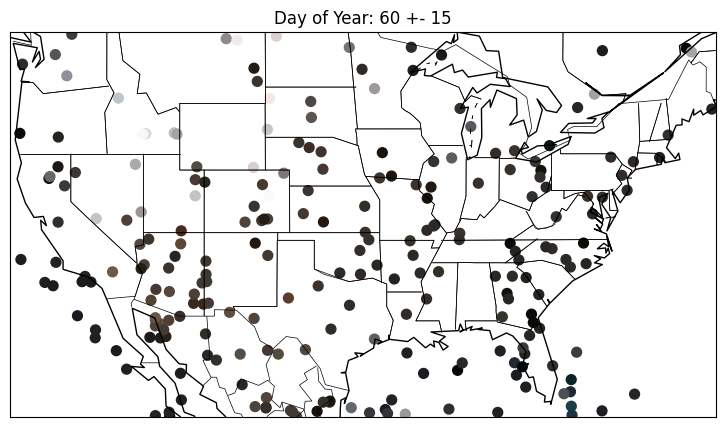

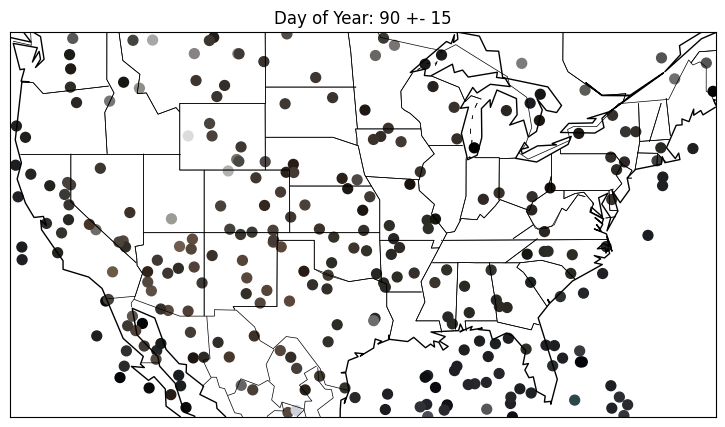

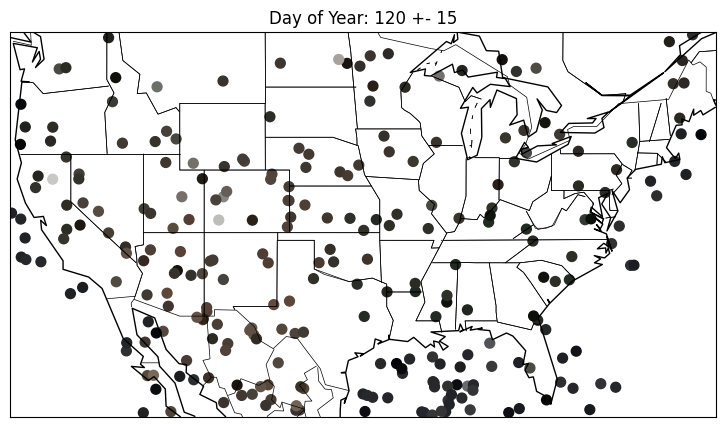

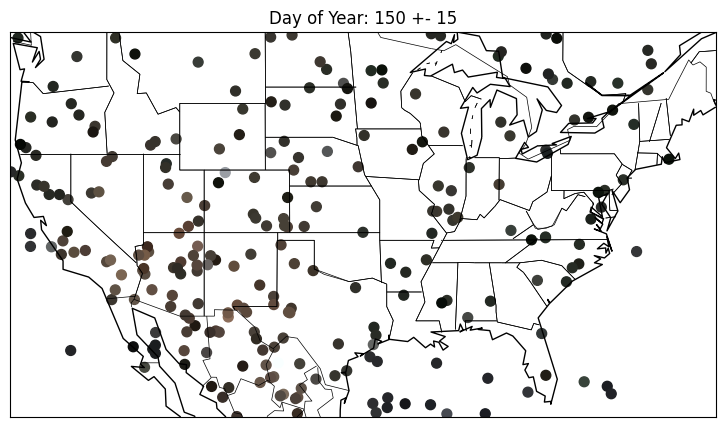

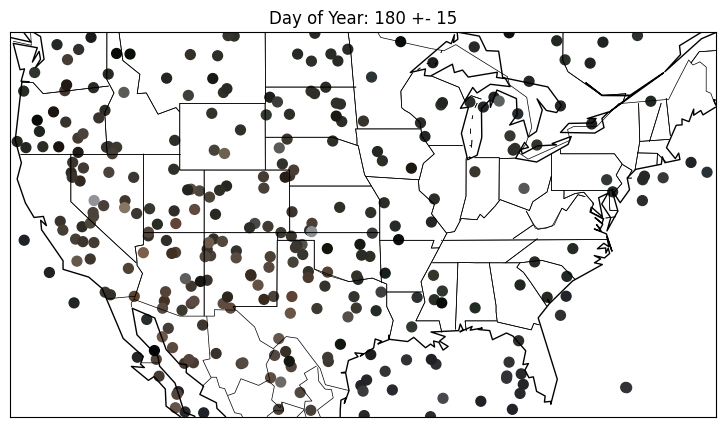

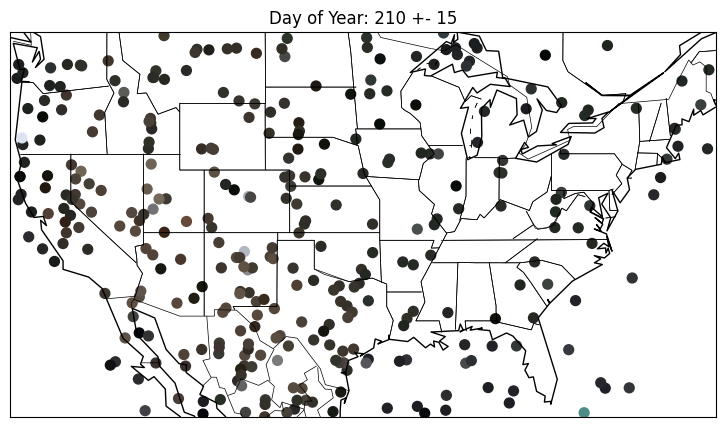

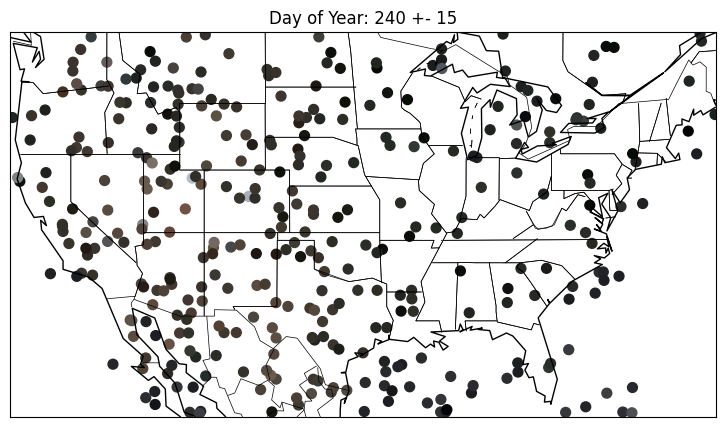

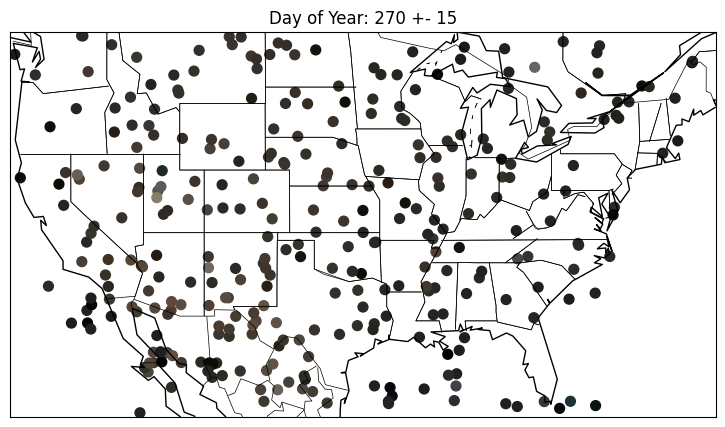

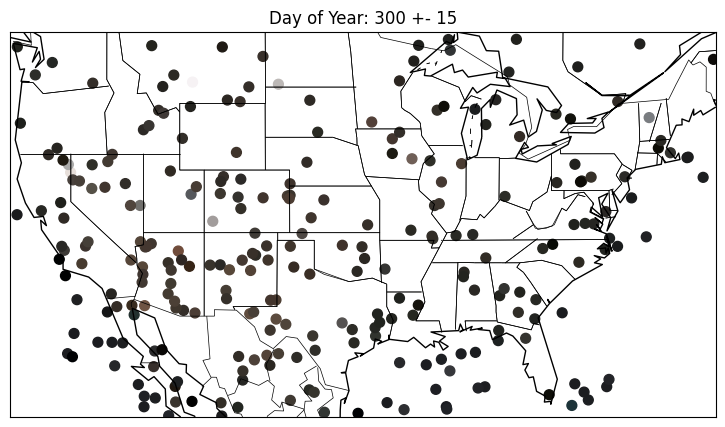

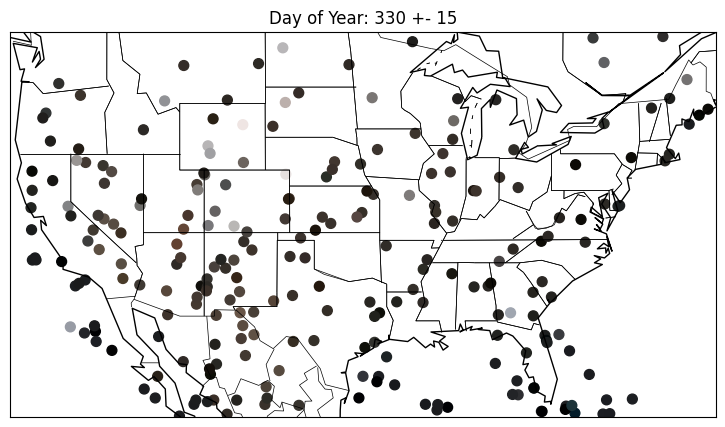

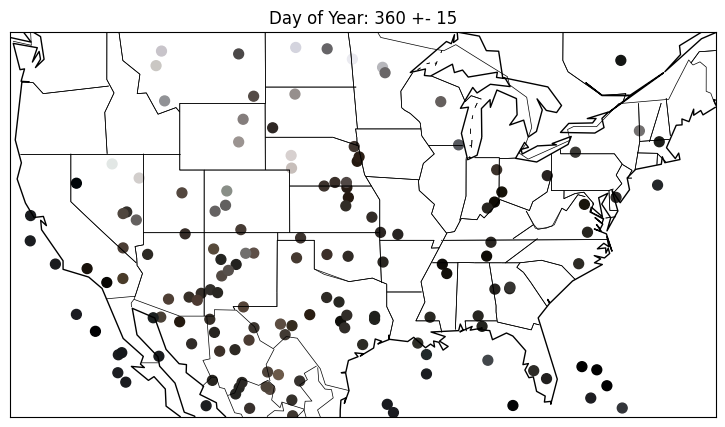

In [ ]:
# Plot smaller scale views
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

# For the continental United States
lons = [-125, -67]
lats = [24, 49]
days_win = 15

frames = []

for doy in tqdm(range(0,365, 30)):
    # Find images within a window of days
    df_window = df[(df['d'] >= doy - days_win) & 
                   (df['d'] <= doy + days_win) & 
                   (df['x'] <= lons[1]) &
                   (df['x'] >= lons[0]) & 
                   (df['y'] >= lats[0]) & 
                   (df['y'] <= lats[1]) ]
    

    cs = np.array([np.array(x) for x in df_window['avg_color'].values])
    cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='merc', 
                lon_0=0,
                llcrnrlat=lats[0], 
                llcrnrlon=lons[0],
                urcrnrlat=lats[1],
                urcrnrlon=lons[1],
                resolution='c', 
                ax=ax)
    m.drawcoastlines()
    m.drawcountries()
    m.drawstates()
    x, y = m(df_window['x'].values, df_window['y'].values)

    sc = ax.scatter(x, y, s=50, c=cs, label="Location")
    ax.set_title(f"Day of Year: {doy} +- {days_win}")
    # ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

# Save as GIF
frames[0].save('s2_temporal_dataset_finegrain_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)



In [ ]:
print(df_window['path'].iloc[0])


/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_10038.tif


In [ ]:
import pandas as pd
import os
from tqdm import tqdm

# Iterate through dataset to check for corrupted files
CHECK_MIN_FILESIZE = 1000  # in bytes
n_skipped_files = 0

# root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k"
root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip"

index_fn = "index.csv"

df = pd.read_csv(os.path.join(root, index_fn))
filenames = []
points = []

n_skipped_files = 0
n_corrupted_files = 0
for i in tqdm(range(df.shape[0])):
    filename = os.path.join(root, "images", df.iloc[i]["fn"])
    
    # Useful for training subsets
    if os.path.exists(filename) == False:
        n_skipped_files += 1
        continue

    if os.path.getsize(filename) < CHECK_MIN_FILESIZE:
        n_skipped_files += 1
        continue
    
    # Ensure it is valid raster
    try:
        
        with rasterio.open(filename) as f:
            data = f.read().astype(np.float32)
    except:
        n_skipped_files += 1
        n_corrupted_files += 1
        print(f"Corrupted file: {filename}")
        continue

    filenames.append(filename)
    points.append(
        (df.iloc[i]["lon"], df.iloc[i]["lat"])
    )

print(f"Number of skipped files: {n_skipped_files}")